# Playground

Helpful links on training troubleshooting:
- [underfitting](https://stats.stackexchange.com/questions/352036/what-should-i-do-when-my-neural-network-doesnt-learn)
- [Unit testing ML](https://thenerdstation.medium.com/how-to-unit-test-machine-learning-code-57cf6fd81765)

In [1]:
import os
import sys
from pathlib import Path
import time
import json
import numpy as np
import diffusers
import xarray as xr
sys.path.append(os.path.abspath("../diffusionsim"))
import torch
import torch.nn as nn
from dataclasses import dataclass, asdict, field
import matplotlib.pyplot as plt
from pprint import pprint
# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
import diffusionsim.training_utils as tru
import diffusionsim.trainers as trainers
import diffusionsim.mydatasets as data
import diffusionsim.evaluations as evals
import diffusionsim as diff

WANDB NOT AVAILABLE


# Debugging Training Classes

In [3]:
from abc import ABC, abstractmethod
from collections import defaultdict
import copy
import dataclasses 

In [4]:
REF_BATCH_SIZE = 128
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
#exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
in_notebook = True
dataset_type="climsim"

## Diffusion Training

In [5]:
def setup_diffusion_run(
    num_models, exp_id, base_run_id, 
    data_vars, 
    image_dim,
    batch_size=128, 
    shuffle_indices=False, 
    use_tendencies=False
):
    dconfig = tru.my_dconfig("gcsfs", data_vars, in_notebook, shuffle_indices, dataset_type, batch_size, use_tendencies)
    dconfig.train_test_split = [0.001]
    tconfigs, mconfigs = [], []
    dconfig.batch_checkpoint_interval = 32
    dconfig.batch_logging_interval = 128
    learning_rates = [1e-5, 1e-5, 1e-5, 1e-5]
    unet_layers_per_block = [1, 1, 2, 2, 1]
    block_out_channels = [
        (32, 32, 64),
        (16, 32, 48),
        (16, 32, 64),
        (32, 48, 64),
    ]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.lr_scheduler = "cosine"
        tconfig.lr_warmup_steps = 200
        tconfig.max_T_sample = 51
        tconfig.clip_gradients = True

        unet = tru.UNetParams()
        if image_dim == 1:
            unet.block_out_channels = block_out_channels[i] #if data_vars == "v1" else None
            unet.down_block_types = ("DownResnetBlock1D", "AttnDownBlock1D", "DownBlock1D") #if data_vars=="v1" else None
            unet.up_block_types = ("UpResnetBlock1D", "AttnUpBlock1D", "UpBlock1D") #if data_vars=="v1" else None
            unet.in_channels = 10 if data_vars == "v1" else 14
        else:
            unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
            unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
            unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
            unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels
        unet.layers_per_block = 1
        unet.norm_num_groups = 4

        scheduler = tru.SchedulerParams()
        scheduler.beta_schedule = "linear"
        scheduler.clip_sample = False
        scheduler.clip_sample_range = 4.0
        scheduler.beta_end = 0.02

        mconfig = tru.ModelConfig(unet=unet, scheduler=scheduler)
        mconfig.model_type = 'ddpm_diffusion1d'
        mconfig.data_vars = data_vars

        tconfigs.append(tconfig)
        mconfigs.append(mconfig)
    return(tconfigs, mconfigs, dconfig)

In [6]:
dconfig = tru.my_dconfig("gcsfs", "v1", True, False, dataset_type, 16, True)
dconfig.train_test_split = [0.001]
dconfig.dataloader_params

DataLoaderParams(batch_size=16, shuffle=True, num_workers=0, prefetch_factor=None, persistent_workers=False, multiprocessing_context=None, pin_memory=False)

In [7]:
tru.DataLoaderParams(batch_size=16)

DataLoaderParams(batch_size=16, shuffle=True, num_workers=0, prefetch_factor=None, persistent_workers=False, multiprocessing_context=None, pin_memory=False)

In [8]:
trainer = None
NUM_MODELS = 4
num_epochs = 15
REF_BATCH_SIZE = 128
dataset_type = "climsim_diffusion1d"
image_dim = 1
data_vars = 'v2'
in_notebook = True

exp_id = "diffusion_hp_search"
base_dir = os.path.join(exp_dir, exp_id)

run_id = "diff_1d_v2"


tconfigs, mconfigs, dconfig = setup_diffusion_run(
    NUM_MODELS, exp_id, run_id, data_vars, image_dim, batch_size=16, shuffle_indices=True, use_tendencies=True
)

dconfig.phases = ['train']

In [31]:
dataloaders, indices = tru.load_dataloaders(dconfig, log=True)

In [32]:
bind = dataloaders[0].dataset.ygen._batch_selectors.selectors
len(bind)

13

In [10]:
import diffusers
from diffusers.models import UNet1DModel

In [76]:
from dataclasses import dataclass, field, asdict
from typing import Tuple, Dict
import torch
@dataclass
class UNetParams:
    sample_size: Tuple[int, int] = field(default_factory=lambda: (16, 24))
    in_channels: int = 10
    out_channels: int = 14
    extra_in_channels: int = 0
    block_out_channels: Tuple = field(default_factory=lambda: (32, 32, 64))  # num output channel for each UNet block
    down_block_types: Tuple = field(default_factory=lambda: (
        "DownResnetBlock1D", "AttnDownBlock1D", "DownBlock1D"
    ))
    up_block_types: Tuple = field(default_factory=lambda: (
        "UpResnetBlock1D", "AttnUpBlock1D", "UpBlock1D"
    ))
    layers_per_block: int = 1
    norm_num_groups: int = 2
    act_fn: str = "silu" # https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/activations.py#L27
    freq_shift: float = 0.0 # fourier freq shift
    use_timestep_embedding: bool = False
    time_embedding_dim: int = 256
    time_embedding_type: str = 'fourier'

params = UNetParams()

model = UNet1DModel(**dataclasses.asdict(params)).to("cuda")

In [77]:
x = sample = torch.randn(4, 10,  64).to("cuda")
t = torch.tensor([5, 5, 5, 5], dtype=torch.long, device=x.device)

In [ ]:

    @register_to_config
    def __init__(
        self,
        sample_size: int = 65536,
        sample_rate: Optional[int] = None,
        in_channels: int = 2,
        out_channels: int = 2,
        extra_in_channels: int = 0,
        time_embedding_type: str = "fourier",
        time_embedding_dim: int = 0,
        flip_sin_to_cos: bool = True,
        use_timestep_embedding: bool = False,
        freq_shift: float = 0.0,
        down_block_types: Tuple[str] = ("DownBlock1DNoSkip", "DownBlock1D", "AttnDownBlock1D"),
        up_block_types: Tuple[str] = ("AttnUpBlock1D", "UpBlock1D", "UpBlock1DNoSkip"),
        mid_block_type: Tuple[str] = "UNetMidBlock1D",
        out_block_type: str = None,
        block_out_channels: Tuple[int] = (32, 32, 64),
        act_fn: str = None,
        norm_num_groups: int = 8,
        layers_per_block: int = 1,
        downsample_each_block: bool = False,
    ):
        super().__init__()
        self.sample_size = sample_size

        # time
        if time_embedding_type == "fourier":
            time_embed_dim = time_embedding_dim or block_out_channels[0] * 2
            if time_embed_dim % 2 != 0:
                raise ValueError(f"`time_embed_dim` should be divisible by 2, but is {time_embed_dim}.")
            self.time_proj = GaussianFourierProjection(
                embedding_size=time_embed_dim // 2, set_W_to_weight=False, log=False, flip_sin_to_cos=flip_sin_to_cos
            )
            timestep_input_dim = time_embed_dim
        elif time_embedding_type == "positional":
            time_embed_dim = time_embedding_dim or block_out_channels[0] * 4
            self.time_proj = Timesteps(
                block_out_channels[0], flip_sin_to_cos=flip_sin_to_cos, downscale_freq_shift=freq_shift
            )
            timestep_input_dim = block_out_channels[0]
        else:
            raise ValueError(
                f"{time_embedding_type} does not exist. Please make sure to use one of `fourier` or `positional`."
            )

In [78]:
temb = model.time_proj(t)
temb.shape

torch.Size([4, 256])

In [74]:
timestep_embed = temb[..., None]
timestep_embed = timestep_embed.repeat([1, 1, sample.shape[2]]).to(sample.dtype)
timestep_embed = timestep_embed.broadcast_to((sample.shape[:1] + timestep_embed.shape[1:]))

In [75]:
timestep_embed.shape

torch.Size([4, 32, 64])

In [50]:
model.time_proj.weight.shape
temb = model.time_proj(t)
temb.shape

torch.Size([1, 256])

In [68]:
model.time_mlp(temb).shape

torch.Size([4, 32])

In [66]:
model.time_mlp

TimestepEmbedding(
  (linear_1): Linear(in_features=32, out_features=256, bias=True)
  (act): SiLU()
  (linear_2): Linear(in_features=256, out_features=32, bias=True)
)

### Cleaning legacy dataclass formats

In [25]:
pkeys = "num_epochs phases distributed_training batch_logging_interval batch_checkpoint_interval log_gradients".split()
delete = True
import inspect
for key in pkeys:
    for run_id in run.run_ids:
        tconfig = run.logs[run_id]['training_config']
        if key in tconfig:
            print(key, tconfig[key])
            if delete and key in inspect.signature(tru.DataConfig).parameters:
                run.logs['data_config'][key] = copy.deepcopy(tconfig[key])
                del tconfig[key]
        else:
            print(key, "not found")
            break

NameError: name 'run' is not defined

In [26]:
rids = run.run_ids
for r in rids:
    tcon = run.logs[r]['training_config']
    run.logs['data_config']['checkpoint_best_epoch'] = tcon['save_best_epoch']
    del tcon['save_best_epoch']

NameError: name 'run' is not defined

## Train Clim

In [21]:

def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128, use_tendencies=True, shuffle_indices=False):
    dataset_type = "climsim"
    #dconfig = tru.my_dconfig("local_vzarr", "v1", in_notebook, False, "climsim")
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, shuffle_indices,
                                dataset_type, batch_size, use_tendencies,
                             )
    dconfig.batch_logging_interval = 1
    dconfig.train_test_split = [0.002, 0.001]
    tconfigs, mconfigs = [], []

    learning_rates = [1e-3, 1e-3, 1e-3, 1e-3] + [1e-3] * max(0, num_models - 4)
    mse_weights = [1.0,] * num_models
    distloss_weights = [0.1,] * num_models
    diffloss_weights = [20.0,] * num_models

    image_dim = 1
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3, 2]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.learning_rate_params.update(dict(
            learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE,
            lr_scheduler="steplr",
            step_size=500,
            gamma=0.95,
            lr_warmup_steps=20,
        ))

        loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        loss_schedule = {'mse': [0,100], 'distribution': [0,100], 'diffusion': [0,100]}
        tconfig.loss_weight_params.update(dict(
            loss_weights=loss_weights,
            loss_schedule=loss_schedule,
            alpha=0.5, 
            strategy="gradnorm",
            update_interval=10,
        ))

        tconfig.clip_gradients = True
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians[:len(target_variables_distloss)]
        
        tconfig.diffusion_image_dim = image_dim
        tconfig.diffusion_loss_noise_level = 10
        tconfig.diffusion_strategy = "1d-encode-decode"
        #tconfig.diffusion_image_loss = "1d-mse"
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(scheduler=tru.SchedulerParams(
            prediction_type="epsilon",
            beta_schedule="linear",
        ))
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

In [22]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "LossWeightTesting"
run_id = "diff_1d_test"
num_models = 4
base_dir = os.path.join(exp_dir, exp_id)

In [25]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    2, exp_id, run_id, data_vars='v1', batch_size=64, use_tendencies=True
)

In [ ]:
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='expanded-low-res',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           num_epochs=10,
           phases=['train', 'eval'],
           train_test_split=[0.002, 0.001],
           dataloader_params=DataLoaderParams(batch_size=128,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=False),
           data_vars='v1',
           use_tendencies=True,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False,
           distributed_training=False,
           c

ModelConfig(model_type='baseline', data_vars='v1', scheduler_type='ddpm', unet=UNetParams(sample_size=(16, 24), in_channels=128, out_channels=128, extra_in_channels=0, block_out_channels=(32, 64, 64, 128), down_block_types=('DownBlock2D', 'DownBlock2D', 'AttnDownBlock2D', 'DownBlock2D'), up_block_types=('UpBlock2D', 'AttnUpBlock2D', 'UpBlock2D', 'UpBlock2D'), layers_per_block=1, norm_num_groups=2, act_fn='silu', freq_shift=0.0, use_timestep_embedding=True), scheduler=SchedulerParams(num_train_timesteps=100, beta_schedule='linear', clip_sample=False, clip_sample_range=4.0, beta_end=0.02, prediction_type='epsilon'), scheduler_inference_steps=100, num_channels=128, latent_dims=16, ae_hidden_dims=[64, 32, 16], disable_enc_logstd_bias=True, bl_model_dir='/mnt/home/ssa2206/Climsim/climsim-online/storage/shared_e3sm/saved_models/wrapper', bl_load_model_name=None, bl_input_size=124, bl_output_size=128, bl_hidden_dims=[256, 256, 256])

In [27]:
dataloaders, indices = tru.load_dataloaders(dconfig, log=False)
ds = dataloaders[0].dataset
dutils = ds.dutils

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [37]:
model_table = {
    'best_diffusion_2d' : ('diffusion_hp_search', 'lr-explore', 'lr-explorea', "best"),
    'vintage_diffusion_2d' : ( "full_dataset_testrun" , 'trial_1b', 'trial_1b', ""),
    'diff_1d_v2' : ('diffusion_hp_search', 'diff_1d', 'diff_1da', ""),
    'diff_1d_v1' : ('diffusion_hp_search', 'diff_1d_v1', 'diff_1d_v1a', "best-"),
}

def load_diffusion_model(model_id='best_diffusion_2d', base_dir="/mnt/home/ssa2206/Climsim/experiments"):
    exp_id, log_id, run_id, cid = model_table[model_id]
    log_dict_path = os.path.join(base_dir, exp_id, f"{log_id}.json")
    with open(log_dict_path, 'r') as file:
        diff_logs = json.load(file)
    mconfig = diff_logs[run_id]['model_config']
    ckpt = os.path.join(base_dir, exp_id, "checkpoints", f"{cid}{run_id}-ckpt.pt")
    if not os.path.exists(ckpt):
        ckpt = os.path.join(base_dir, exp_id, "checkpoints", log_id,f"{cid}{run_id}-ckpt.pt")
    model = tru.load_model_from_ckpt(ckpt, mconfig)
    return(model)

In [38]:
unet = load_diffusion_model("diff_1d_v1")
scheduler = tru.load_scheduler(mconfigs[0])

In [39]:
trainer = self = trainers.ClimsimTrainer(dataloaders, indices, mconfigs, tconfigs, base_dir, 
                                run_id, rank=0, unet=unet.to(device), scheduler=scheduler)

In [ ]:
trainer.train(1, log=False)

Getting ready to train 2 model(s) for 1 epochs on device cpu; configs at /mnt/home/ssa2206/Climsim/experiments/LossWeightTesting/diff_1d_test.json
Epoch 0/0
__________
________________________________________________
Currently at train epoch 0, step 0/3
________________________________________________


In [ ]:
def diffusion_loss(trainer, y_hat, run_id):
    #raise NotImplementedError("Diffusion loss not implemented")
    # TODO: y and yhat are of size (B, 128) and somehow need to convert into images for diffusion loss
    tconfig = trainer.training_configs[run_id]
    scheduler = trainer.schedulers[run_id]
    image_dim = 2 if "2" in tconfig.diffusion_strategy else 1
    y_image = trainer._make_image(y_hat, image_dim)
    def encode(sample):
        eps = torch.randn(sample.shape, device=sample.device) # BS x C x H x W
        xt = scheduler.add_noise(sample, eps, torch.LongTensor([tconfig.diffusion_loss_noise_level])) # noisy image
        return(xt)
    def decode(xt):
        og = xt.detach().clone()
        dists = []
        dist = torch.nn.MSELoss()
        with torch.no_grad():
            for t in range(tconfig.diffusion_loss_noise_level, 0, -tconfig.diffusion_loss_decoding_interval):
                eps_theta = trainer.unet(xt, t).sample
                xt = scheduler.step(eps_theta, t, xt).prev_sample
                dists.append(dist(og, xt).item())
        return(xt, dists)
    if "encode" in tconfig.diffusion_strategy:
        y_image = encode(y_image)
    y_image_denoised, dists = decode(y_image)
    return(tru.image_loss(tconfig)(y_image_denoised, y_image), dists)

In [ ]:
l, rdists = diffusion_loss(trainer, y, run_id)
l

tensor(0.0407, device='cuda:0')

In [ ]:
l, fdists = diffusion_loss(trainer, y_hat, run_id)
l

tensor(0.0420, device='cuda:0', grad_fn=<MseLossBackward0>)

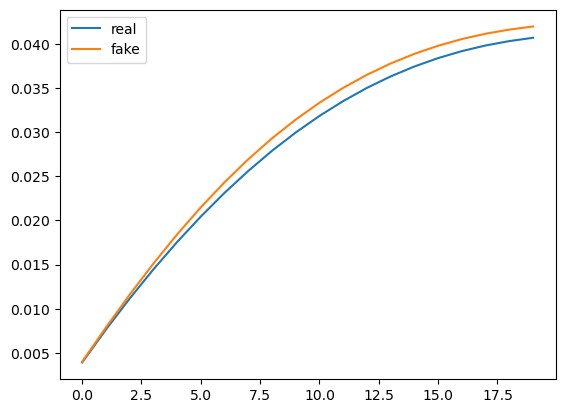

In [ ]:
plt.plot(rdists, label="real")
plt.plot(fdists, label="fake")
plt.legend()

In [ ]:
unet2d = tru.load_diffusion_model()

In [ ]:
run2d = evals.Run("diffusion_hp_search", "lr-explore", climsim_run = False, cid='best')
trainer = run2d.reconstruct_trainer(apply_checkpoints=True, apply_indices=False)

/srv/conda/envs/notebook/lib/python3.12/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
losses, self.loss_weights[run_id]

(tensor([1.5882e-02, 4.3194e+03, 4.1961e-02], device='cuda:0',
        grad_fn=<StackBackward0>),
 tensor([2.0310e-01, 1.6816e-04, 2.7967e+00], device='cuda:0',
        requires_grad=True))

In [ ]:
trainer.current_epoch = 7
trainer._return_loss_weights(tconfigs[3])

### Sanity Checking run_batch

In [ ]:
run = evals.Run()

In [ ]:
import copy

def params_of(model):
    return [p.detach().clone() for p in model.parameters()][-2]

In [ ]:
og_models = [copy.deepcopy(trainer.models[run_id]) for run_id in trainer.run_ids]

In [ ]:
import copy

for key in trainer.models:
    model = copy.deepcopy(og_models[0])
    tconfig = trainer.training_configs[key]
    trainer.models[key] = model
    print(params_of(trainer.models[key])[:2, :2], "\n")
    self.optimizers[key] = tru.create_optimizer(model, tconfig)


In [ ]:
x, y = next(iter(trainer.dataloaders['train']))

In [ ]:
import torch

initial_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    initial_weights[key] = param.detach().clone()

batch_losses, params, after_params = _run_batch(trainer, x, y, phase='train', step=0)
new_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    new_weights[key] = param.detach().clone()
    print(f"{key} updated:", not torch.allclose(param, initial_weights[key]))

In [ ]:
params[0] == after_params[0]

In [ ]:
after_params[0]

In [ ]:
self = trainer
for run_id, grads in self.gradients.items():
    print(run_id, trainer.training_configs[run_id].loss_weights)
    for loss_type, gradloss in grads.items():
        print(loss_type, gradloss['2.weight'])``
    print()

In [ ]:
[trainer.training_configs[run_id].num_gaussians for run_id in trainer.run_ids]

## VAE Training

In [93]:
x = torch.tensor([7.0, 1, 5, 6, 2, 7, 2, 9]).to(device)
y = x * x
y.shape

model = torch.nn.Sequential(
    torch.nn.Linear(8, 16),
    torch.nn.ReLU(),
    torch.nn.Linear(16, 8),
).to(device)
optim = torch.optim.Adam(model.parameters())

losses = []
loss = 10
loss_fn = torch.nn.MSELoss()
step = 0
while loss > 0.1:
    pred = model(x)
    loss = loss_fn(pred, y)
    optim.zero_grad()
    loss.backward()
    optim.step()
    losses.append(loss.item())
    step += 1

In [94]:
step, len(losses)

(866, 866)

# Training behavior  - Diffusion

In [8]:
def plot_profile(data, var_index=None, ax=None, title='', **kwargs):
    if torch.is_tensor(data):
        data = data.detach().cpu().numpy()
    assert data.ndim < 4, "no more than 3d"
    if data.ndim == 3:
        assert var_index is not None, "need to specify variable"
        data = data[:, var_index, :]
    elif(data.ndim == 2 and data.shape[0] == 10):
        data = data[var_index]
    levels = np.arange(data.shape[-1])
    if ax is None:
        fig, ax = plt.subplots()
    if data.ndim == 1:
        im = ax.plot(data, levels, **kwargs)
    else:
        if 'labels' in kwargs and len(kwargs['labels']) == len(data):
            labels = kwargs['labels']
            print(labels)
        for i, profile in enumerate(data): 
            im = ax.plot(profile, levels, label=labels[i])
    plt.legend()
    ax.invert_yaxis()
    ax.set_ylabel("Level index (0 = top)")
    ax.set_title(title)
    if var_index is not None: 
        ax.set_xlabel(ds.target_vars[var_index])
    return(im)

In [11]:
trainer = None
NUM_MODELS = 1
num_epochs = 100
REF_BATCH_SIZE = 128
dataset_type = "climsim_diffusion1d"
image_dim = 1
data_vars = 'v1'
in_notebook = True

exp_id = "diffusion_hp_search"
base_dir = os.path.join(exp_dir, exp_id)

run_id = "diff_onesampletest"


tconfigs, mconfigs, dconfig = setup_diffusion_run(
    NUM_MODELS, exp_id, run_id, data_vars, image_dim, batch_size=16, shuffle_indices=False, use_tendencies=False
)
dconfig.train_test_split, dconfig.phases = [0.001], ['train']
dconfig.batch_logging_interval = 1
dconfig.batch_checkpoint_interval = 100
dconfig.checkpoint_best_epoch = False
pprint(dconfig)

DataConfig(dataset_type='climsim_diffusion1d',
           climsim_type='low-res-expanded',
           source='gcsfs',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           num_epochs=10,
           phases=['train'],
           train_test_split=[0.001],
           dataloader_params=DataLoaderParams(batch_size=16,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=False),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           shuffle_indices=False,
           distributed_training=False,
           checkpoint_best_epoch=False,
           

In [12]:
dataloaders, indices = data.load_dataloaders(dconfig, log=False)

In [13]:
dl = dataloaders[0]
ds = dl.dataset
y = next(iter(dl))

In [15]:
from diffusionsim import nvidia_modulus

In [16]:
dutils = ds.dutils

In [17]:
scheduler = tru.load_scheduler(mconfigs[0])
scheduler.prediction_type = "epsilon"
scheduler

DDPMScheduler {
  "_class_name": "DDPMScheduler",
  "_diffusers_version": "0.35.1",
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_start": 0.0001,
  "clip_sample": false,
  "clip_sample_range": 4.0,
  "dynamic_thresholding_ratio": 0.995,
  "num_train_timesteps": 100,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "steps_offset": 0,
  "thresholding": false,
  "timestep_spacing": "leading",
  "trained_betas": null,
  "variance_type": "fixed_small"
}

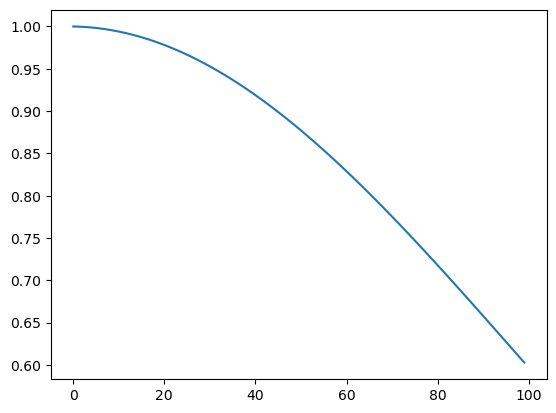

In [18]:
plt.plot(torch.sqrt(scheduler.alphas_cumprod.cpu()))

In [106]:
y[:,0,:].std()

tensor(2.4469)

In [107]:
y.mean(), y.std()

(tensor(-0.0732), tensor(1.7244))

In [158]:
x0 = y[::3][::5][::7][:16].to(device)
eps = torch.randn(x0.shape, device=device)
timesteps = torch.full((x0.shape[0],), 80, device=device, dtype=torch.long)
xt = scheduler.add_noise(x0, eps, timesteps)

In [159]:
alpha_bar = scheduler.alphas_cumprod[timesteps].to(device)
print("aplpha bar   ", alpha_bar[0])
while len(alpha_bar.shape) < len(x0.shape):
    alpha_bar = alpha_bar.unsqueeze(-1)
vt = torch.sqrt(alpha_bar) * eps - torch.sqrt(1 - alpha_bar) * x0
vt.shape
torch.sqrt(alpha_bar[0,0]), torch.sqrt(1 - alpha_bar[0,0]), 

aplpha bar    tensor(0.5153, device='cuda:0')


(tensor([0.7179], device='cuda:0'), tensor([0.6962], device='cuda:0'))

/tmp/ipykernel_7939/2887710082.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


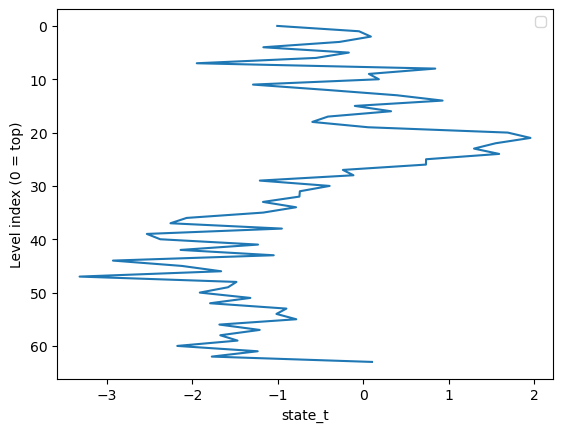

In [160]:
i = 4
plot_profile(vt[i], var_index=0)

['vt', 'x0']


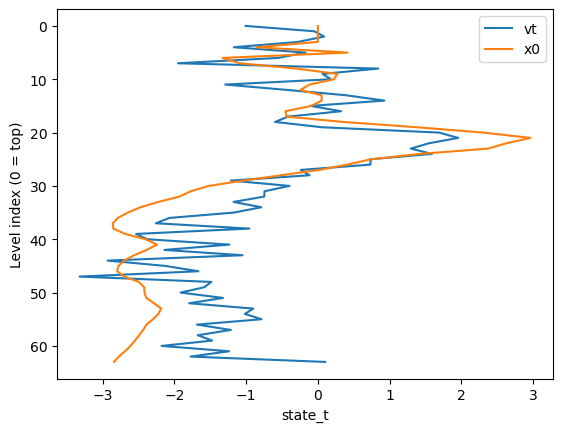

In [161]:
plot_profile(torch.cat([vt[i:i+1], -x0[i:i+1]], axis=0), var_index=0, labels='vt x0'.split())

In [167]:
#TODO : try zeuyan unet to see of lower loss floor
model = unet = self = nvidia_modulus.ClimsimUnet(
    num_vars_profile=len([v for v in dutils.input_vars if v in dutils.level_variables]),
    num_vars_scalar=len([v for v in dutils.input_vars if v in dutils.normal_variables]),
    num_vars_profile_out=len([v for v in dutils.target_vars if v in dutils.level_variables]),
    num_vars_scalar_out=len([v for v in dutils.target_vars if v in dutils.normal_variables]),
    diffusion_mode = True,
    model_channels= 64,
    kernel_size=3,
    channel_mult = [1, 8, 8, 8],
    attn_resolutions=[], conditioning_resolutions={64:[], 32:[], 16 : [], 8 : []},
    dropout=0.0, 
    
).to(device)

In [164]:
x0.var(), vt.var(), eps.var()

(tensor(2.3207, device='cuda:0'),
 tensor(1.6338, device='cuda:0'),
 tensor(0.9929, device='cuda:0'))

In [166]:
target = eps
target is eps

True

In [168]:
loss = 10
loss_fn = torch.nn.MSELoss()
#trainer = self = DiffusionTrainerTest(dataloaders, indices, mconfigs, tconfigs, base_dir, run_id)
optimizer = torch.optim.Adam(model.parameters(),lr=0.0001)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.9)
losses, lrs = [], []
step = 0
while loss > 0.10 and step < 1000:
    pred = model(xt, timesteps)
    loss = loss_fn(pred, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    lr_scheduler.step()
    lrs.append(lr_scheduler.get_last_lr()[0])
    step += 1 
print("done!")

done!


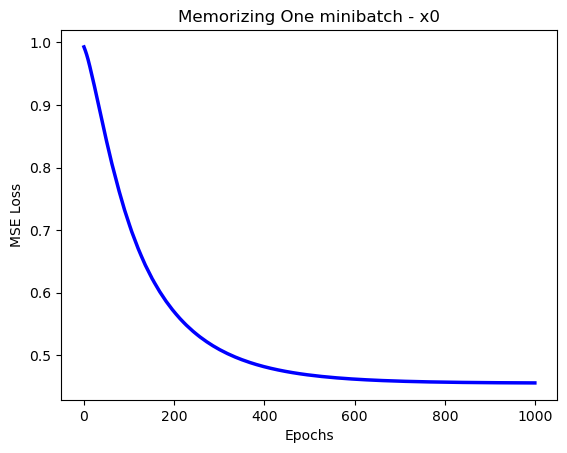

In [169]:
plt.plot(losses, color='blue', linewidth=2.50)
plt.title("Memorizing One minibatch - x0")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

In [146]:
target = vt/2

In [147]:
pred = model(xt, timesteps)

In [154]:
losses[-1]

0.11632554978132248

In [148]:
loss_fn(pred,target) 

tensor(0.1163, device='cuda:0', grad_fn=<MseLossBackward0>)

In [149]:
with torch.no_grad():
    for channel in range(x0.shape[1]):
        print(i, loss_fn(pred[:,channel], target[:,channel]))

4 tensor(0.1874, device='cuda:0')
4 tensor(0.0917, device='cuda:0')
4 tensor(0.0968, device='cuda:0')
4 tensor(0.2045, device='cuda:0')
4 tensor(0.1130, device='cuda:0')
4 tensor(0.0710, device='cuda:0')
4 tensor(0.1013, device='cuda:0')
4 tensor(0.1032, device='cuda:0')
4 tensor(0.0890, device='cuda:0')
4 tensor(0.1052, device='cuda:0')


In [84]:
pred[8:9].shape

torch.Size([1, 10, 64])

In [94]:
(x0/2).var(), x0.var()

(tensor(0.5802, device='cuda:0'), tensor(2.3207, device='cuda:0'))

['prediction', 'vt/2']


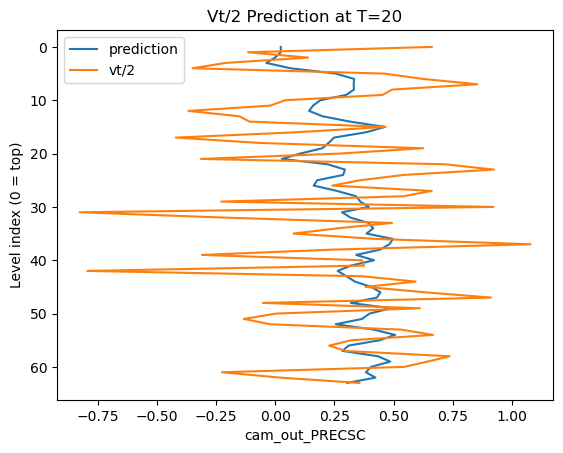

In [157]:
#fig, ax = plt.subplots(1, 1)
im1 = plot_profile(torch.cat([pred[i:i+1], target[i:i+1]], dim=0), 4, labels='prediction vt/2'.split())
plt.title("Vt/2 Prediction at T=20")
plt.show()

['x0', 'vt']


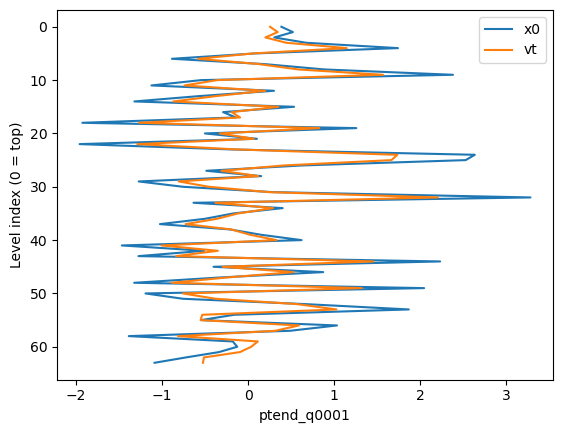

In [83]:
c2 = torch.cat([eps[i:i+1], vt[i:i+1]], dim=0)
im1 = plot_profile(c2, 1, labels='x0 vt'.split())
plt.show()

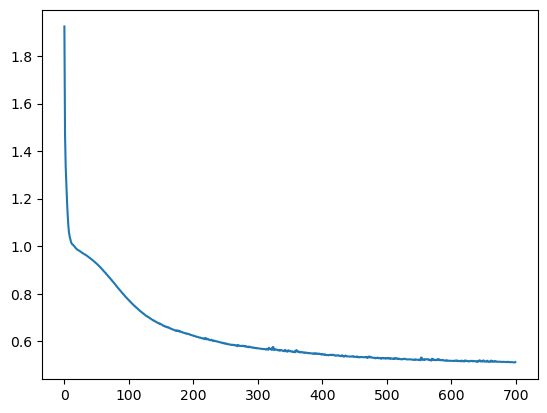

In [97]:
plt.plot(trainer.losses['diff_onesampletesta']['train'])
plt.show()

In [ ]:
ddpm = run

In [23]:
evals.plot_loss(run)

# Training Behavior - Climsim

In [ ]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "climsim"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [0.001, 0.001]
    #dconfig.shuffle_indices = Tr
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 1e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.0, 0.0, 0.01, 0.01] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [0.0, 10.0, 0.0, 10.0]
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3, 2]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        tconfig.loss_schedule = {'mse': 0, 'distribution': 5, 'diffusion': 5}
        tconfig.clip_gradients = True
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

In [ ]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    num_models, exp_id, run_id, data_vars='v1', batch_size=64
)

trainer = ClimsimTrainer(dconfig, mconfigs, tconfigs, 
                torch.nn.MSELoss(), base_dir, run_id, rank=0)

In [183]:
AbstractTrainer = trainers.AbstractTrainer
class DiffusionTrainerTest(AbstractTrainer):
    def __init__(self, dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id, **kwargs):
        super().__init__(dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id)
        self.scheduler = tru.load_scheduler(mconfigs[0])
    
    def _run_batch(self, images, phase='train'):
        batch_losses = {}
        for run_id in self.run_ids:
            model, optimizer = self.models[run_id], self.optimizers[run_id]
            tconfig, lr_scheduler = self.training_configs[run_id], self.lr_schedulers[run_id]
            #noisy_images = self.scheduler.add_noise(images, noises, timesteps)
            #noisy_images = og_noisy # images + sigma * noises
            noise_pred = model(noisy_images, 5).sample
            loss = self.loss_fn(noise_pred, noises)
            if(phase == 'train'):
                optimizer.zero_grad()
                loss.backward()
                if(tconfig.clip_gradients and False):
                    total_grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if(lr_scheduler is not None):
                    lr_scheduler.step()
            batch_losses[run_id] = loss.item()
        return(batch_losses)

    def _run_epoch(self, images, timesteps, phase='train'):
        for run_id in self.run_ids:
            self.models[run_id].train(phase=='train')
        with torch.set_grad_enabled(phase=='train'):
            if(self.distributed):
                self.dataloaders[phase].sampler.set_epoch(self.current_epoch)
            dl = self.dataloaders[phase]
            for step in range(len(dl)):
                batch_losses = self._run_batch(images, timesteps, phase)
                self.log_step(batch_losses, step, phase)
                del batch_losses

    def log_step(self, batch_losses, step, phase):
        
        if(step % self.bli == 0 or step+1 == len(self.dataloaders[phase])):
            for run_id in self.run_ids:
                self.losses.setdefault(run_id, defaultdict(list))[phase].append(batch_losses[run_id])

        if ((step+1) % self.ckpt_interval == 0 and phase == 'train'): 
            for run_id in self.run_ids:
                self._save_checkpoint(run_id)
    
    def _log_epoch_info(self, phase='train'):
        for run_id in self.run_ids:
            ind = self.batches_per_epoch[phase] // self.bli + 1
            epoch_losses = self.losses[run_id][phase][-ind:]
            avg_loss = sum(epoch_losses) / max(len(epoch_losses), 1)
            if self.current_epoch % 25 == 0:
                print(f"avg loss for epoch {self.current_epoch}, {run_id=}: {avg_loss}", flush=True)
            if(avg_loss < self.best_losses.setdefault(run_id, float('inf')) and phase=="train"):
                self.best_losses[run_id] = avg_loss


## Validating Errors

Including incidents of nan or anything else

In [ ]:
def score_function(x, mu, var, pi, clamp_val=10, epsilon=1e-7):
    mahal = (x[:,None] - mu) ** 2 / (2 * var)
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - torch.clamp(mahal, max=clamp_val)
    qx = torch.exp(torch.logsumexp(log_probs, dim=1, keepdim=True)) + epsilon
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * torch.clamp((x[:,None] - mu) / var, max=clamp_val, min=-clamp_val)  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()

def u_q(x_1, x_2, mu, var, pi, h):
    assert len(x_1.shape) == 1 and len(x_2.shape) == 1, "expected 1d input"
    # x_1 and x_2 are samples from q(x), compared to knowledge distribution p(x) represented by mixture model. Thus, they are of shape (n_samples, d)
    sq1 = score_function(x_1, mu, var, pi)
    sq2 = score_function(x_2, mu, var, pi)

    print(sq1.isnan().any(), sq2.isnan().any())

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return torch.outer(sq1, sq2)
    
    diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
    res = torch.outer(sq1, sq2)
    res += (sq1.reshape(-1,1) * diffs) / h**2
    res -= (sq2.reshape(1, -1) * diffs)/h**2
    res += (h**-2 - h**-4 * diffs ** 2)
    res = res * torch.exp(- (diffs ** 2) / (2 * h ** 2)) # kernel matrix
    return(res)

In [ ]:
trainer.bli = 1
trainer.train(1, log=True)

### Investigating Incidents

In [ ]:
from diffusionsim.evaluations import *

In [ ]:
incident  = trainer.nan_incidents['trial1b'][0]
print(incident.keys())
for name, p in incident['state_dict'].items():
    print(name, p.shape, torch.isnan(p).any())



In [ ]:
sample_model = tru.build_baseline_model(mconfigs[0]).to(device)
sample_model.eval()
sample_model.load_state_dict(incident['state_dict'])


In [ ]:
x, y = trainer.dataloaders['train'].dataset[335]
x, y = x.to(device), y.to(device)
y_hat = sample_model(x)
print(y_hat.shape, y.shape)
distribution_loss(trainer, y_hat, y, tconfigs[0], 0) # nan? 

In [ ]:
plt.hist(y[:, VAR_IND].detach().cpu().numpy(), bins=50, density=True, alpha=0.5, label='Data')
plt.show()

In [ ]:
x = torch.linspace(-2, 0, 1000)
density, = eval_density(x, GMM)
plt.plot(x, density)

In [ ]:
d = plot_gmm_distribution(y[:,VAR_IND].reshape(-1, 1), GMM)

In [ ]:
means_grads = {}
stds_grads = {}

for k in trainer.gradients['trial1d'].keys():
    means_grads[k] = []
    stds_grads[k] = []
    loss_grads = trainer.gradients['trial1d'][k]
    for name, stats in loss_grads.items():
        if(name == '2.weight'):
            for mean, std in stats:
                means_grads[k].append(mean)
                stds_grads[k].append(std)

# Trying to Improve Training

## Overfitting two samples

two_sample_ds = ClimsimImageDataset(Xarr[:2*384], Yarr[:2*384], mconfig, device=device, normalize=True)

In [ ]:
#two_sample_dl = DataLoader(two_sample_ds, shuffle=tconfig.shuffle_data['train'], batch_size=2)
two_sample_dl = DataLoader(two_sample_ds, shuffle=tconfig.shuffle_data['train'], batch_size=2)
batch = next(iter(two_sample_dl))
noisy_images, timesteps, noise = two_sample_dl.dataset.noise_batch(batch)

optimizer = diff.trainers.create_optimizer(model, tconfig)
lr_scheduler = load_lr_scheduler(tconfig, optimizer, two_sample_dl)

In [ ]:
pred = model(noisy_images, timesteps).sample
loss = loss_fn(pred, noise)
loss

NameError: name 'noisy_images' is not defined

In [ ]:
loss.backward()

In [ ]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

In [ ]:
torch.norm(list(model.parameters())[0].grad)

In [ ]:
set = {'train' : two_sample_ds}
trainer = DiffusionTrainer(model, dset, loss_fn, tconfig, mconfig, exp_id='two_sample_diffusion')
#trainer.dataloaders = {'train' : two_sample_dl}
#trainer.batch = next(iter(two_sample_dl)) # use same noise every time
trainer.train(1000)

In [ ]:
plt.plot(trainer.losses)

## 

In [ ]:
from diffusers.optimization import get_cosine_schedule_with_warmup

optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
lr_scheduler = load_lr_scheduler(tconfig, )

## Experimenting with Accelerators

In [ ]:
from diffusers import DDPMPipeline
from diffusers.utils import make_image_grid
from accelerate import Accelerator
from huggingface_hub import create_repo, upload_folder
from tqdm.auto import tqdm
from pathlib import Path

def evaluate(config, epoch, pipeline):
    # Sample some images from random noise (this is the backward diffusion process).
    # The default pipeline output type is `List[PIL.Image]`
    images = pipeline(
        batch_size=config.eval_batch_size,
        generator=torch.Generator(device=device).manual_seed(config.seed), # Use a separate torch generator to avoid rewinding the random state of the main training loop
    ).images

    # Make a grid out of the images
    image_grid = make_image_grid(images, rows=4, cols=4)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

In [ ]:
def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator and tensorboard logging
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        #log_with="tensorboard",
        project_dir=os.path.join(config.output_dir, "logs"),
    )
    if accelerator.is_main_process:
        if config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        if config.push_to_hub:
            repo_id = create_repo(
                repo_id=config.hub_model_id or Path(config.output_dir).name, exist_ok=True
            ).repo_id
        accelerator.init_trackers("train_example")


    # Prepare everything
    # There is no specific order to remember, you just need to unpack the
    # objects in the same order you gave them to the prepare method.
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    # Now you train the model
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, clean_images in enumerate(train_dataloader):
            # Sample noise to add to the images
            noise = torch.randn(clean_images.shape, device=clean_images.device)
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device,
                dtype=torch.int64
            )

            # Add noise to the clean images according to the noise magnitude at each timestep
            # (this is the forward diffusion process)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        # After each epoch you optionally sample some demo images with evaluate() and save the model
        try:
            if accelerator.is_main_process:
                pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)
    
                if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                    evaluate(config, epoch, pipeline)
    
                if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                    if config.push_to_hub:
                        upload_folder(
                            repo_id=repo_id,
                            folder_path=config.output_dir,
                            commit_message=f"Epoch {epoch}",
                            ignore_patterns=["step_*", "epoch_*"],
                        )
                    else:
                        pipeline.save_pretrained(config.output_dir)
        except: 
            print("Ran into error with sampling and evaluating")
        
        return(model)

In [ ]:
from accelerate import notebook_launcher

args = (config, model, noise_scheduler, optimizer, dataloader, lr_scheduler)

model = notebook_launcher(train_loop, args, num_processes=1)